<a href="https://colab.research.google.com/github/new2datasci/Deep-learning-architectures/blob/main/Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><h1>1-e: Transformers</h1></center>
<center><h2><a href="https://rdfia.github.io/">Course link</a></h2></center>


# Warning :
# Do "File -> Save a copy in Drive" before you start modifying the notebook, otherwise your modifications will not be saved.

In this notebook, we will implement the first Visual Transformer, [ViT](https://arxiv.org/abs/2010.11929). We'll implement a naive version of it, much smaller than the ones described in the paper, and we also won't use complex data augmentation and regularizations. But note that this is important to make transformers work in practice on large-scale dataset.

To get a gist of what is required to make a transformer work in practice, have a look at the [DeiT and CaiT codebase](https://github.com/facebookresearch/deit).

This notebook is a simplified version of the excellent [Timm library](https://github.com/rwightman/pytorch-image-models).

In [ ]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
import pickle
import math

import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.utils as vutils
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
import torch
torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
%pip install -q torchmetrics==1.4.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.2/869.2 kB 46.5 MB/s eta 0:00:00


Let's load the MNIST dataset:

In [ ]:
transform = transforms.Compose([
  transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST('.', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST('.', train=False, download=True, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


... and visualize!

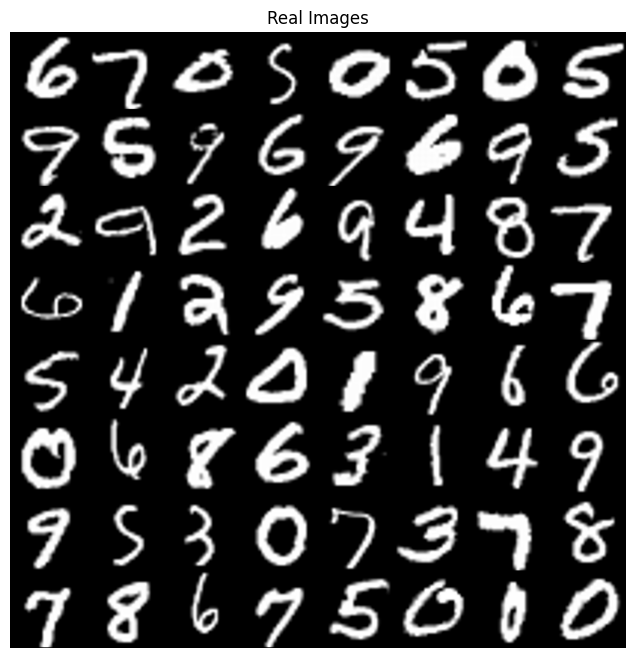

In [ ]:
real_batch = next(iter(train_loader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Real Images")
plt.imshow(vutils.make_grid(real_batch[0][:64], normalize=True).permute(1,2,0))
plt.show()

# Here is the general architecture of the ViT model
## The architecture includes:
- A step for splitting the image into disjoint patches with a linear projection of the patches
- Positional encoding to capture the absolute spatial information of each patch in the image
- The addition of a "[CLS]" token, initialized randomly and learned during training
- A transformer encoder that learns the representation of each token
- A classification head that performs class prediction from the re-embedded [CLS] token at the output of the encoder

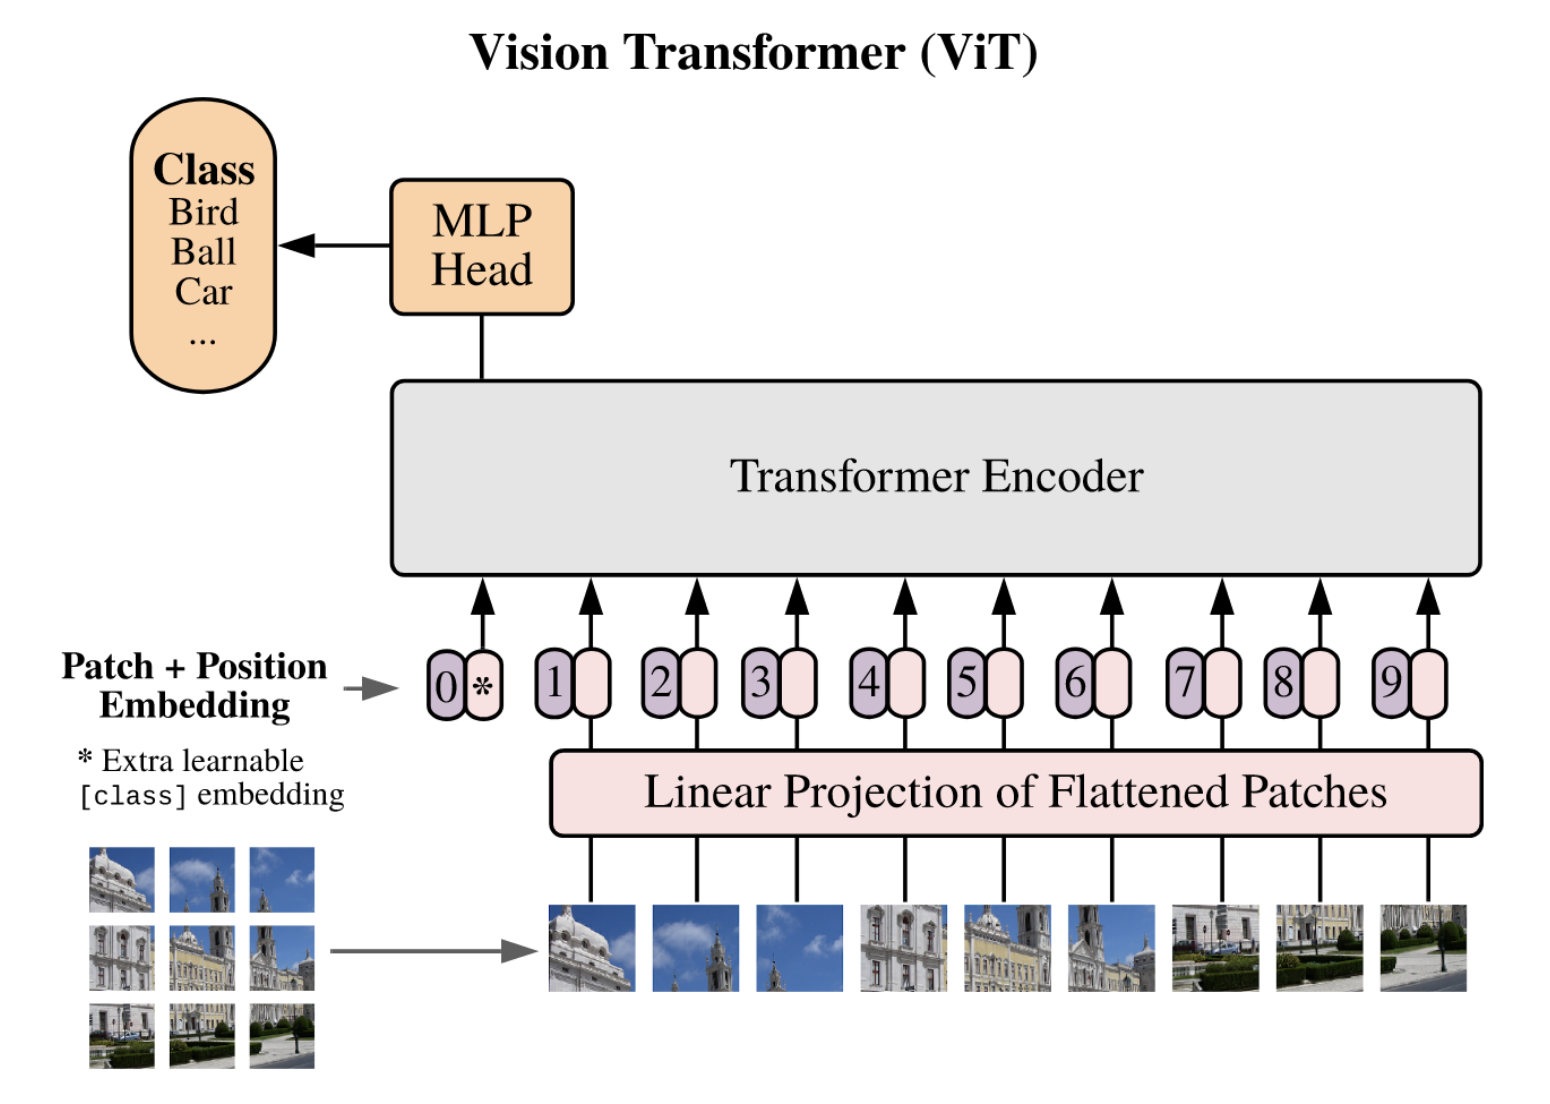

# Linear Projection of flattened patches

**Q1**:
First, we need to code the patch embedding. In NLP, it could be using a word2vec embeddings, but we need something different in Computer Vision.

You are going to use a specific 2d convolution to play the role of the so-called "Linear Projection" on the image above and process each patch independently without overlap. Think a bit how you could do that.

Then, you need to manipulate the dimensions of the resulting tensor to get a final tensor of shape `(batch_size, nb_tokens, embedding_dim)`. *Hint: You will need a `view/reshape` and `transpose/permute` operators*.

As usual, remember to check the output shape of your layer by trying with a random tensor!

In [ ]:
class PatchEmbed(nn.Module):
    def __init__(self, in_chan=1, patch_size=7, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        # Conv2d with kernel_size == stride gives non-overlapping patches
        self.projection = nn.Conv2d(
            in_channels=in_chan,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
            padding=0,
            bias=True
        )

    def forward(self, x):
        # x: (B, in_chan, H, W)
        B, _, H, W = x.shape
        assert H % self.patch_size == 0 and W % self.patch_size == 0, \
            f"Image size {(H, W)} must be divisible by patch_size={self.patch_size}"
        x = self.projection(x)           # (B, embed_dim, H/ps, W/ps)
        B, C, Hp, Wp = x.shape
        x = x.flatten(2).transpose(1, 2) # (B, Hp*Wp, C) = (B, N, embed_dim)
        return x


In [ ]:
# Random tensor, MNIST-like size
pe = PatchEmbed(in_chan=1, patch_size=7, embed_dim=128)
y = pe(torch.randn(2, 1, 28, 28))
print(y.shape)  # => torch.Size([2, 16, 128])  (since 28/7 = 4, N = 4*4 = 16)

# Try on a real MNIST batch
imgs, labels = next(iter(train_loader))   # imgs: (B,1,28,28)
tokens = pe(imgs)
print(tokens.shape)  # (B, 16, 128)


torch.Size([2, 16, 128])


RuntimeError: Given groups=1, weight of size [128, 1, 7, 7], expected input[64, 3, 224, 224] to have 1 channels, but got 3 channels instead

# Transformer encoder

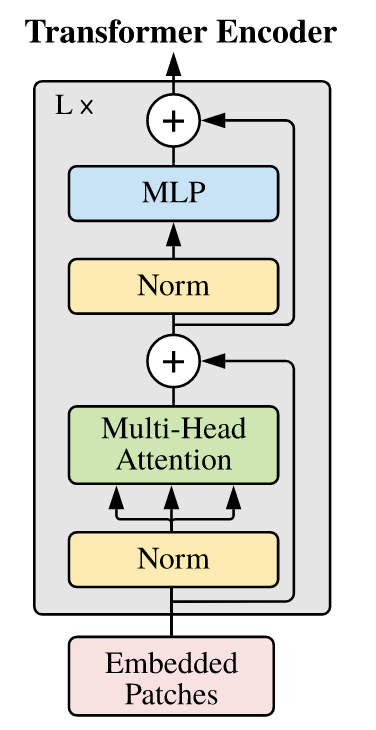

## Q2: MLP

Now we need to build a transformer block. Let's first build the easiest part, the MLP! By now, you should be confident how to code one.

Code a MLP with one hidden layer. Note that the input and output dimensions will be the same. Instead of ReLU, use the activation GELU, which is a slight alternative often used for transformers.

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_features, hid_features, p=0.0):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hid_features)
        self.act = nn.GELU()
        self.drop = nn.Dropout(p)
        self.fc2 = nn.Linear(hid_features, in_features)

    def forward(self, x):                # x: (B, N, C)
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

# Sanity check
print(MLP(128, 512)(torch.randn(32, 16, 128)).shape)  # -> torch.Size([32, 16, 128])


torch.Size([32, 16, 128])


## Q3: Self-attention

Now we are going to build the famous **Self-Attention**.
- What is the main feature of self-attention, especially compared to its convolutional counterpart. What is its main challenge in terms of computation/memory?
- At first, we are going to only consider the simple case of one head. Write the equations and complete the following code. And don't forget a final linear projection at the end!




In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.q = nn.Linear(embed_dim, embed_dim, bias=True)
        self.k = nn.Linear(embed_dim, embed_dim, bias=True)
        self.v = nn.Linear(embed_dim, embed_dim, bias=True)
        self.out = nn.Linear(embed_dim, embed_dim, bias=True)

    def forward(self, x):                # x: (B, N, C)
        B, N, C = x.shape

        # Q, K, V: (B, N, C)
        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        # scaled dot-product attention
        # scores: (B, N, N)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(C)

        # attention weights along last dim (over keys)
        attn = F.softmax(scores, dim=-1)

        # weighted sum of values: (B, N, C)
        context = torch.matmul(attn, v)

        # final linear projection
        x = self.out(context)            # (B, N, C)
        return x

# Sanity check
print(SelfAttention(128)(torch.randn(32, 16, 128)).shape)  # -> torch.Size([32, 16, 128])


torch.Size([32, 16, 128])


# Q4 : Multi-head self-attention

Now we need to build a Multi-Heads Self-Attention.
- Write the equations and complete the following code to build a Multi-Heads Self-Attention.
- The total embedding size will be shared equally among all heads.

**Answers in the report**

In [ ]:
class MultiHeadsSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        head_dim = embed_dim // num_heads

        self.num_heads = num_heads
        self.head_dim = head_dim
        self.scale = head_dim ** -0.5

        # Linear projections to full embed_dim, we’ll reshape into heads later
        self.q = nn.Linear(embed_dim, embed_dim, bias=True)
        self.k = nn.Linear(embed_dim, embed_dim, bias=True)
        self.v = nn.Linear(embed_dim, embed_dim, bias=True)
        self.projection = nn.Linear(embed_dim, embed_dim, bias=True)

    def forward(self, x):                         # x: (B, N, C)
        B, N, C = x.shape

        # Project
        q = self.q(x)                             # (B, N, C)
        k = self.k(x)                             # (B, N, C)
        v = self.v(x)                             # (B, N, C)

        # Split into heads: (B, N, H, d) -> (B, H, N, d)
        q = q.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        # Shapes now: (B, H, N, d)

        # Scaled dot-product attention per head
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale   # (B, H, N, N)
        attn = F.softmax(scores, dim=-1)                             # (B, H, N, N)
        context = torch.matmul(attn, v)                              # (B, H, N, d)

        # Merge heads: (B, H, N, d) -> (B, N, H*d=C)
        context = context.transpose(1, 2).contiguous().view(B, N, C) # (B, N, C)

        # Final output projection
        x = self.projection(context)                                 # (B, N, C)
        return x

# Sanity check
x = torch.randn(4, 10, 6)  # (B=4, N=10, C=6)
print(MultiHeadsSelfAttention(6, 2)(x).shape)  # -> torch.Size([4, 10, 6])


torch.Size([4, 10, 6])


# Q5: Transfomer block

Now, we need to build a Transformer **Block** as described in the image below.
- Write the equations and complete the following code.
- For the Layer Normalization, use PyTorch LayerNorm: https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html

**Answers in the report** 😀



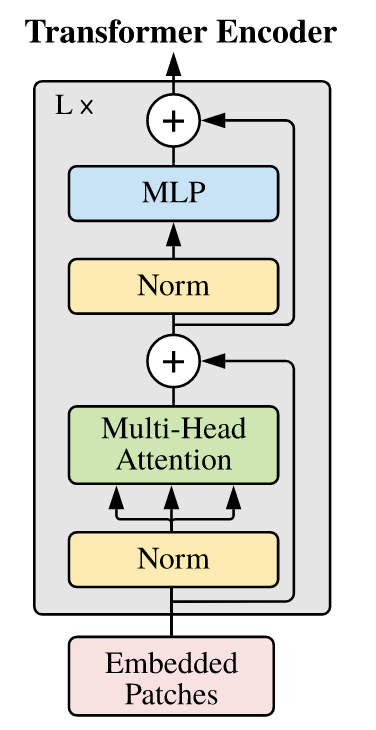

In [ ]:
class Block(nn.Module):
    def __init__(self, embed_dim, num_heads=4, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadsSelfAttention(embed_dim, num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = MLP(in_features=embed_dim, hid_features=int(embed_dim*mlp_ratio))

    def forward(self, x):           # x: (B, N, C)
        x = x + self.attn(self.norm1(x))   # residual 1
        x = x + self.mlp(self.norm2(x))    # residual 2
        return x

# Sanity check
print(Block(128)(torch.randn(32, 16, 128)).shape)  # -> torch.Size([32, 16, 128])


torch.Size([32, 16, 128])


# Q6: Full ViT model

Now you need to build a ViT model based on what you coded in the previous questions. There are additional components that should be coded such as the Class token, Positional embedding and the classification head.

- Explain what is a Class token and why we use it? \\
- Explain whay is the the positional embedding (PE) and why it is important? \\

For PE, you can use a sinusoidal encoding (see below), or fully learned.


**Answers in the report** 😀

### Sinusoidal PE


In [ ]:
def get_positional_embeddings(sequence_length, d):
    result = torch.ones(1,sequence_length, d)
    for i in range(sequence_length):
        for j in range(d):
            result[0][i][j] = np.sin(i / (10000 ** (j / d))) if j % 2 == 0 else np.cos(i / (10000 ** ((j - 1) / d)))
    return result

In [ ]:
class ViT(nn.Module):
  def __init__(self, embed_dim, nb_blocks, patch_size, nb_classes=10, num_heads=4, mlp_ratio=4):
    super().__init__()

    num_patches = (28 // patch_size) ** 2

    self.class_token = nn.Parameter(torch.ones(1, embed_dim),requires_grad=False)
    self.pos_embed = nn.Parameter(self.get_positional_embeddings(num_patches+1, embed_dim), requires_grad=False)
    self.patch_embed = PatchEmbed(patch_size=patch_size, embed_dim=embed_dim)

    blocks = []
    for _ in range(nb_blocks):
      blocks.append(Block(embed_dim, num_heads=num_heads, mlp_ratio=num_heads))
    self.blocks = nn.Sequential(*blocks)

    self.norm = nn.LayerNorm(embed_dim)
    self.head = nn.Sequential(
            nn.Linear(embed_dim, nb_classes),
            nn.Softmax(dim=-1)
        )

  @staticmethod
  def get_positional_embeddings(sequence_length, d):
    """
    given the number of tokens and the dimensionality of each of them,
    outputs a matrix where each coordinate (i,j) is the value to be added to token i in dimension j.
    """
    result = torch.ones(1,sequence_length, d)
    for i in range(sequence_length):
        for j in range(d):
            result[0][i][j] = np.sin(i / (10000 ** (j / d))) if j % 2 == 0 else np.cos(i / (10000 ** ((j - 1) / d)))
    return result

  def forward(self, x):
    batch_size = x.size(0)
    x = self.patch_embed(x) ## image to patches => B, N, C

    ## concatenating class token of shape (1, embedding dim) for every example
    x = torch.cat((self.class_token.repeat(batch_size, 1, 1), x), dim=1)

    ## adding positional embedding
    x += self.pos_embed.repeat(batch_size, 1, 1)

    ## forward in the transformer
    x = self.blocks(x)[:, 0, :] # We take only the CLS token

    ## Normalize the output
    x = self.norm(x)

    output = self.head(x) ## classification output

    return output

  # Sanity check
print(ViT(128, 3, 7)(torch.randn(32, 1, 28, 28)).shape)  # -> torch.Size([32, 10])



torch.Size([32, 10])


# Q7: Experiment on MNIST!

A quick function to evaluate our model:

In [ ]:
%pip install -q torchmetrics==1.4.2


In [ ]:
@torch.no_grad()
def eval_model(model, loader, num_classes):
  model.eval()
  acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=num_classes).cuda()
  loss = 0

  for x, y in loader:
    x, y = x.cuda(), y.cuda()
    yhat = model(x)
    loss += F.cross_entropy(yhat, y)
    acc(yhat.argmax(dim=1), y)

  model.train()
  return loss.item() / len(loader), acc.compute().item()

And run! Feel free to try other hyperparameters.

In [ ]:
import torchmetrics
from tqdm import tqdm
from torchmetrics.functional import accuracy as tm_accuracy
def main(epochs = 10, embed_dim = 32, patch_size = 7, nb_blocks = 2, num_classes=10, num_heads=4, mlp_ratio=4, model=None, tqdm_batch=False, lr=0.001):
  if not model:
    model = ViT(embed_dim, nb_blocks, patch_size, num_heads=num_heads, mlp_ratio=mlp_ratio).cuda()
  if tqdm_batch:
    train_loader_main = tqdm(train_loader)
  else:
    train_loader_main = train_loader
  opt = torch.optim.Adam(model.parameters(), lr=lr)
  acc_train = torchmetrics.classification.Accuracy(task="multiclass", num_classes=num_classes).cuda()
  acc_train_list = []
  acc_test_list = []
  loss_train_list = []
  loss_test_list = []

  for epoch in (pbar := tqdm(range(epochs))):
    train_loss = 0.
    for x, y in train_loader_main:
      x, y = x.cuda(), y.cuda()

      opt.zero_grad()
      yhat = model(x)
      loss = F.cross_entropy(yhat, y)
      loss.backward()

      opt.step()
      acc_train(yhat.argmax(dim=1), y)
      train_loss += loss.item()
    loss_train_list.append(train_loss / len(train_loader))
    acc_train_list.append(acc_train.compute().item())
    acc_train.reset()

    # Test eval
    loss_test, acc_test = eval_model(model, test_loader, num_classes)
    acc_test_list.append(acc_test)
    loss_test_list.append(loss_test)
    pbar.set_description(f"acc_train {acc_train_list[-1]:.3f} | acc_test {acc_test:.3f}")
  return acc_train_list, acc_test_list, loss_train_list, loss_test_list



# Experimental analysis
- Test different hyperparameters and explain how they affect the performance. In particular embed_dim, patch_size, and nb_blocks.
- Comment and discuss the final performance that you get. How to improve it?
-  What is the complexity of the transformer in terms of number of tokens? How you can improve it?

In [ ]:
def plot_plot_optimizers(plot_optimizers, save_name=None):
    fig, ax = plt.subplots(2, 2, figsize=(15, 10))
    ax = ax.flatten()

    for opt, values in plot_optimizers.items():
        ax[0].plot(values[0], label=f"{opt}")
        ax[1].plot(values[1], label=f"{opt}")
        ax[2].plot(values[2], label=f"{opt}")
        ax[3].plot(values[3], label=f"{opt}")

    ax[0].set_title("Train accuracy / epoch")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].set_ylim([0, 1])

    ax[1].set_title("Test accuracy / epoch")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_ylim([0, 1])

    ax[2].set_title("Train loss / epoch")
    ax[2].set_xlabel("Epoch")
    ax[2].set_ylabel("Loss")

    ax[3].set_title("Test loss / epoch")
    ax[3].set_xlabel("Epoch")
    ax[3].set_ylabel("Loss")

    plt.legend()
    plt.tight_layout()
    if save_name:
        plt.savefig(f"{save_name}.pdf", dpi=100, bbox_inches="tight")
    plt.show()

In [ ]:
plot_optimizers_nb_blocks = {}
for nb_blocks in [2,4,6,8]:
    stats = main(epochs=25, nb_blocks=nb_blocks)
    plot_optimizers_nb_blocks[nb_blocks] = stats

acc_train 0.981 | acc_test 0.974: 100%|██████████| 25/25 [04:32<00:00, 10.90s/it]
acc_train 0.976 | acc_test 0.973: 100%|██████████| 25/25 [05:26<00:00, 13.08s/it]
acc_train 0.973 | acc_test 0.972: 100%|██████████| 25/25 [06:21<00:00, 15.28s/it]
acc_train 0.973 | acc_test 0.970: 100%|██████████| 25/25 [07:17<00:00, 17.52s/it]


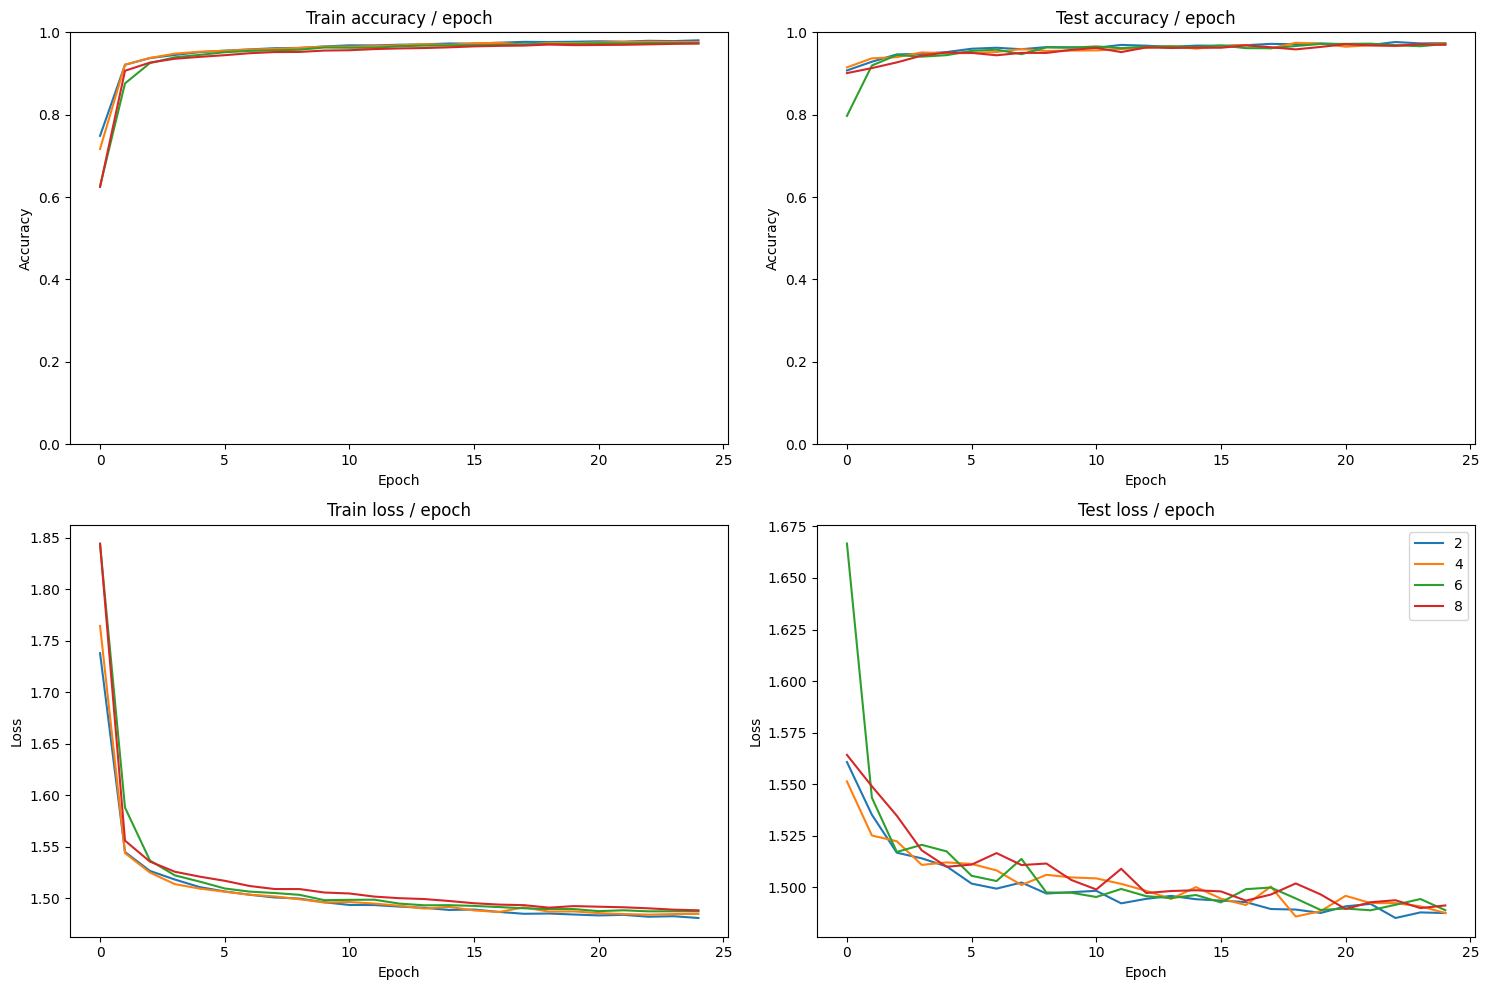

In [ ]:
plot_plot_optimizers(plot_optimizers_nb_blocks, 'nb_block_influence')


In [ ]:
plot_optimizers_embed_dim = {}
for embed_dim in [16,32,64,128]:
    stats = main(epochs=25, embed_dim=embed_dim)
    plot_optimizers_embed_dim[embed_dim] = stats

acc_train 0.969 | acc_test 0.964: 100%|██████████| 25/25 [04:35<00:00, 11.01s/it]
acc_train 0.977 | acc_test 0.967: 100%|██████████| 25/25 [04:35<00:00, 11.02s/it]
acc_train 0.979 | acc_test 0.972: 100%|██████████| 25/25 [04:36<00:00, 11.08s/it]
acc_train 0.975 | acc_test 0.972: 100%|██████████| 25/25 [04:37<00:00, 11.10s/it]


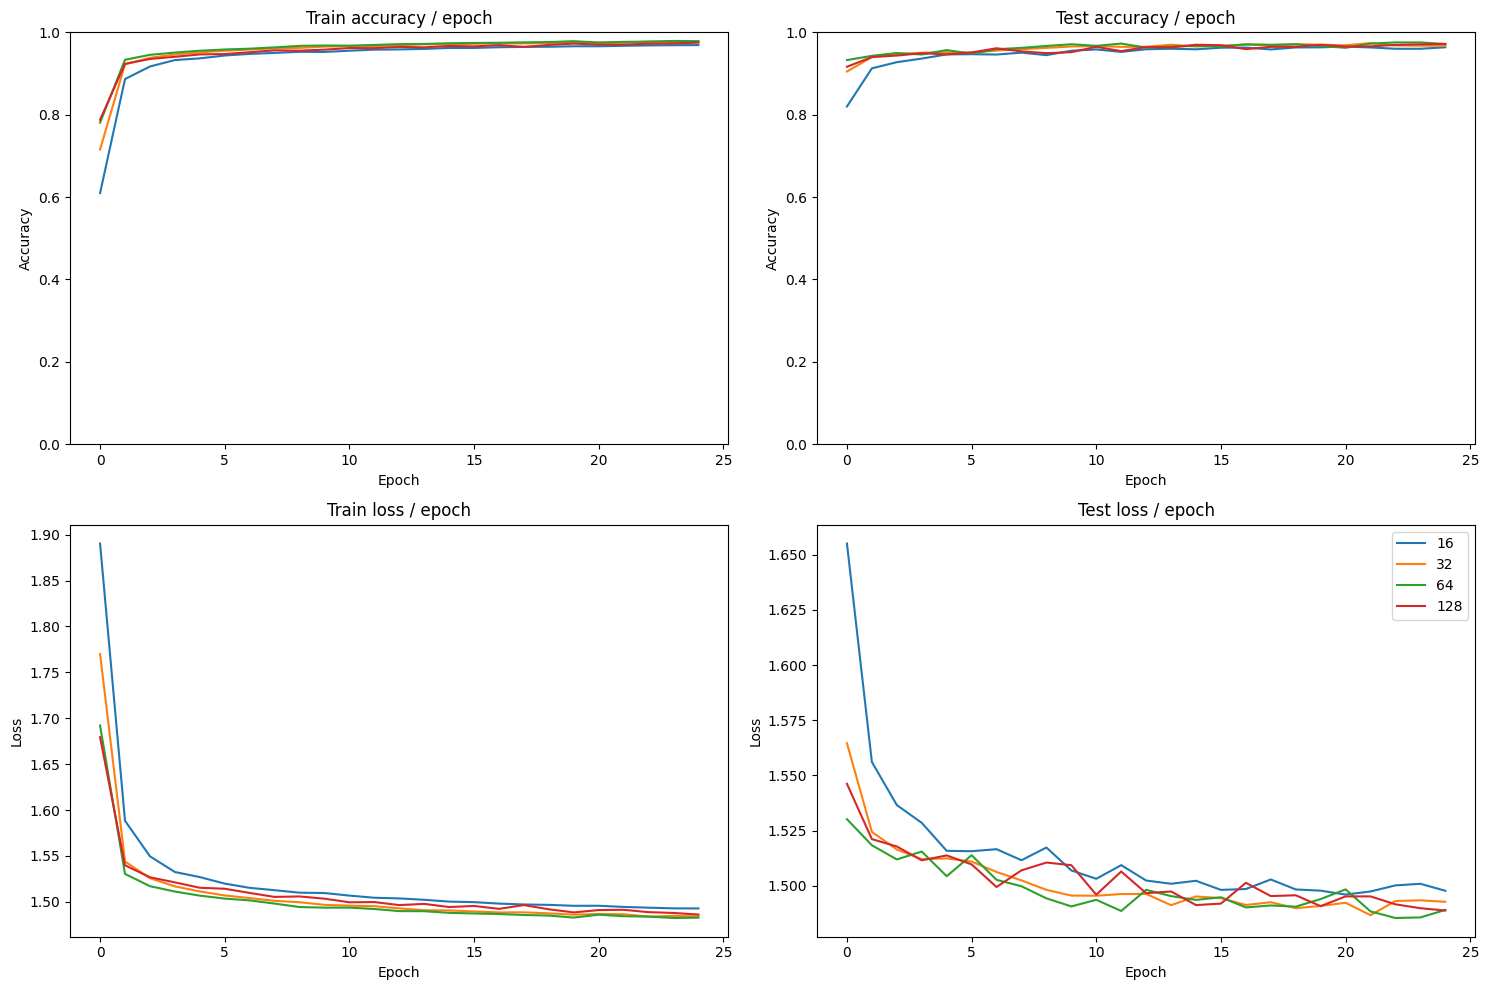

In [ ]:
plot_plot_optimizers(plot_optimizers_embed_dim, 'embed_dim_influence')


In [ ]:
plot_optimizers_patch_size = {}
for patch_size in [2,4,7,14, 28]:
    stats = main(epochs=25, patch_size=patch_size)
    plot_optimizers_patch_size[patch_size] = stats

acc_train 0.974 | acc_test 0.972: 100%|██████████| 25/25 [06:40<00:00, 16.00s/it]
acc_train 0.978 | acc_test 0.977: 100%|██████████| 25/25 [04:36<00:00, 11.08s/it]
acc_train 0.978 | acc_test 0.967: 100%|██████████| 25/25 [04:35<00:00, 11.01s/it]
acc_train 0.984 | acc_test 0.971: 100%|██████████| 25/25 [04:34<00:00, 10.98s/it]
acc_train 0.978 | acc_test 0.967: 100%|██████████| 25/25 [04:35<00:00, 11.04s/it]


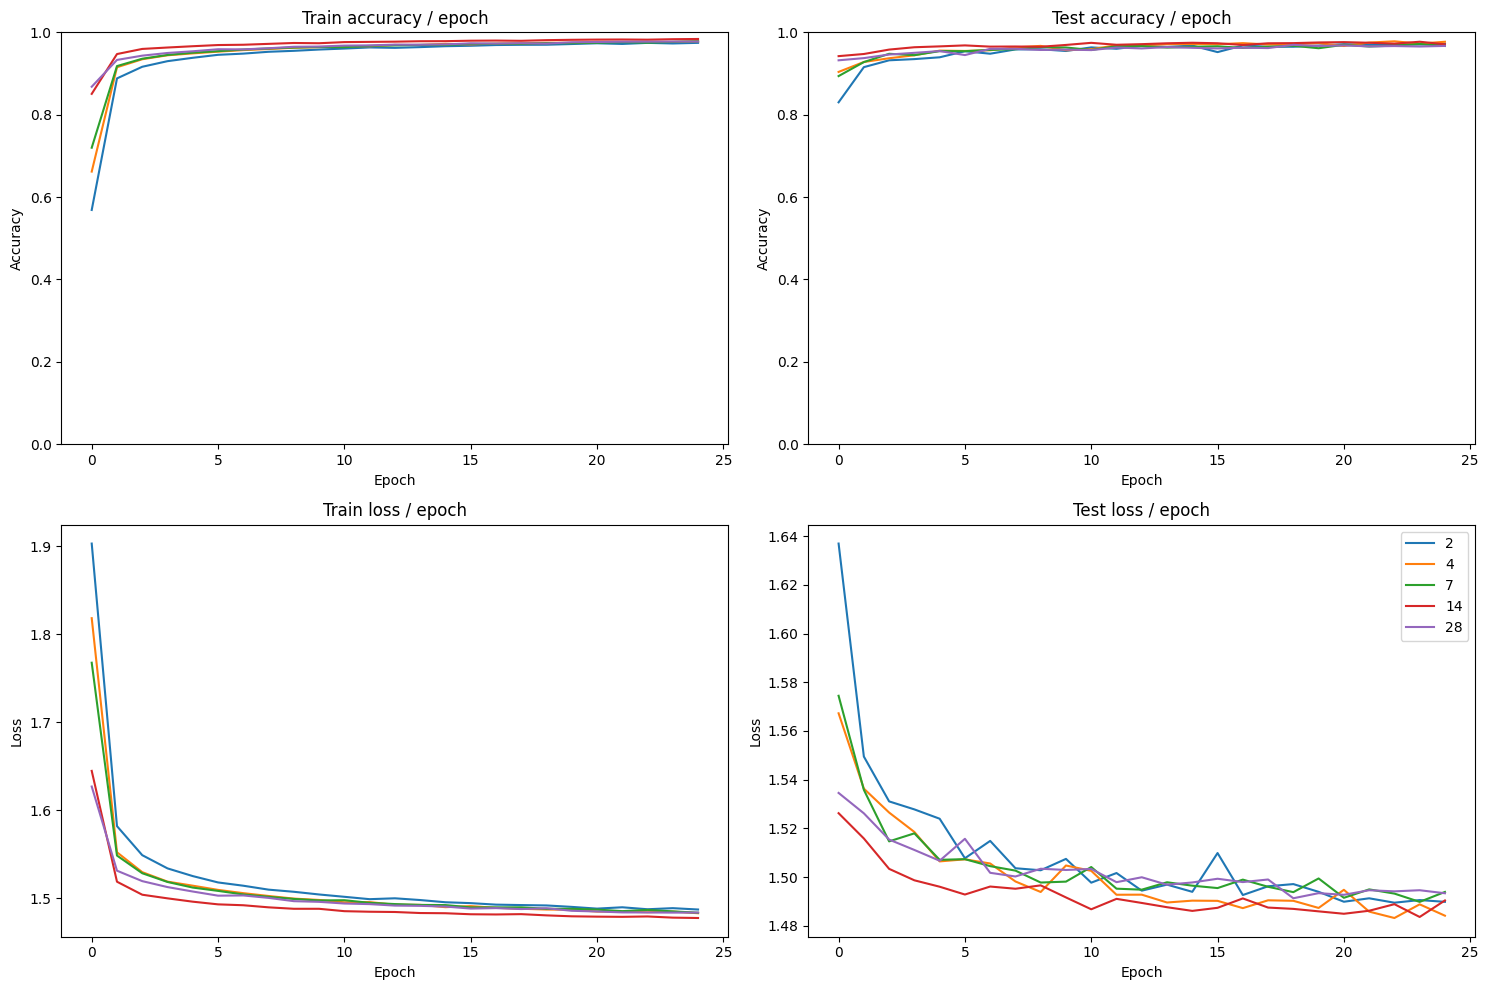

In [ ]:
plot_plot_optimizers(plot_optimizers_patch_size, 'patch_size_influence')

In [ ]:
plot_optimizers_num_heads = {}
for num_heads in [2,4,8,16]:
    stats = main(epochs=25, num_heads=num_heads)
    plot_optimizers_num_heads[num_heads] = stats

acc_train 0.972 | acc_test 0.966: 100%|██████████| 25/25 [04:33<00:00, 10.96s/it]
acc_train 0.977 | acc_test 0.976: 100%|██████████| 25/25 [04:34<00:00, 10.99s/it]
acc_train 0.983 | acc_test 0.976: 100%|██████████| 25/25 [04:34<00:00, 10.97s/it]
acc_train 0.982 | acc_test 0.977: 100%|██████████| 25/25 [04:34<00:00, 10.98s/it]


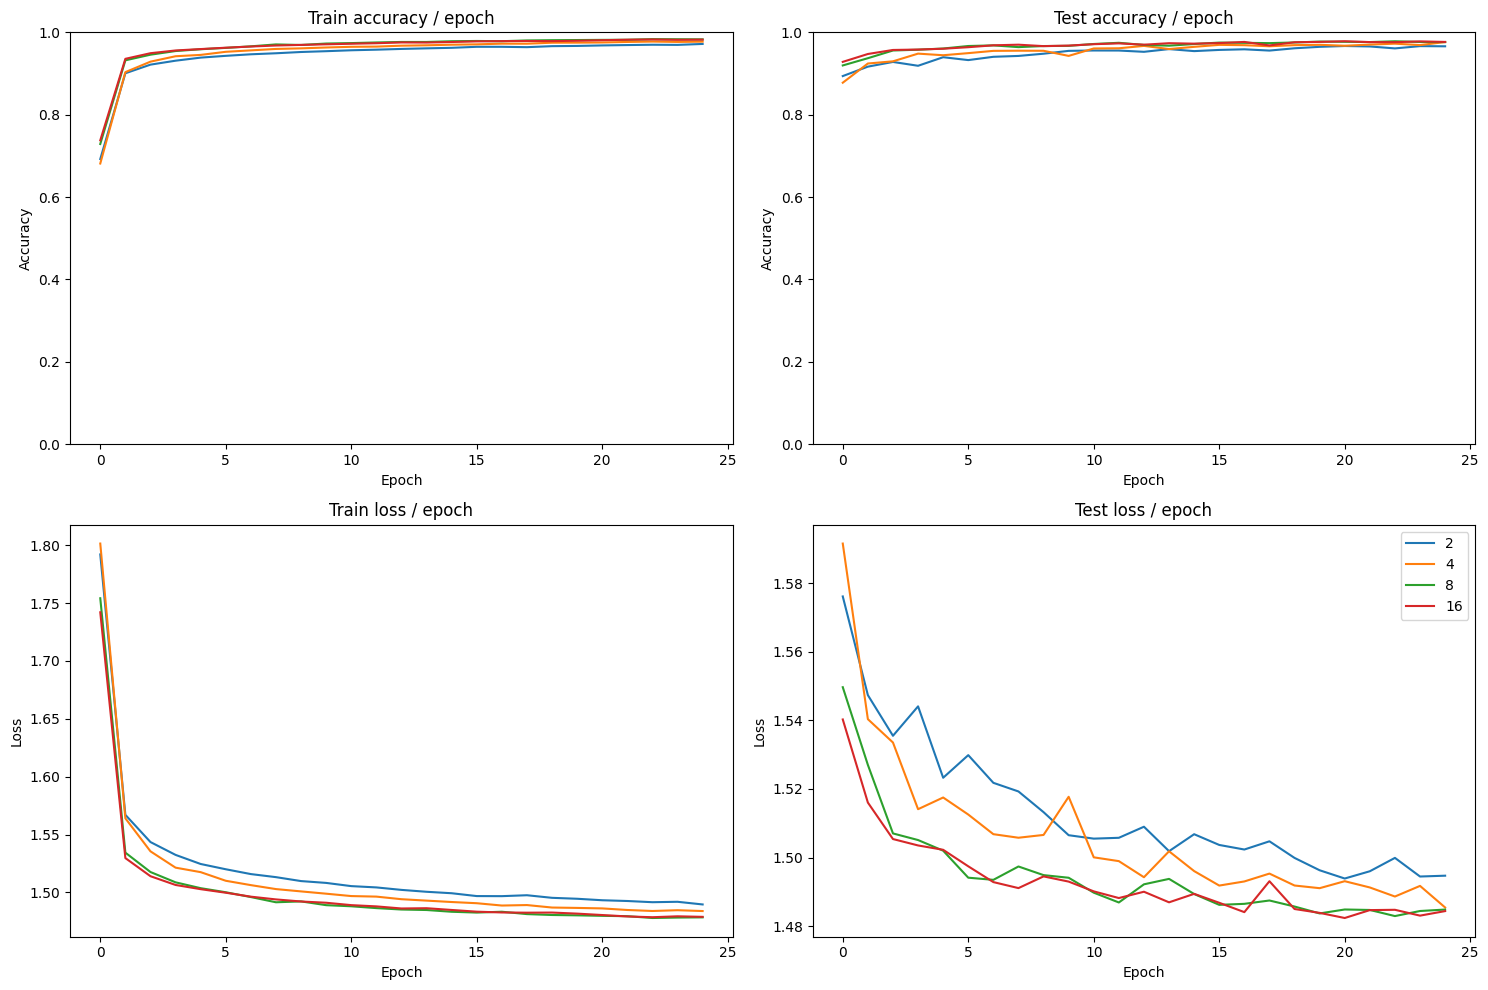

In [ ]:
plot_plot_optimizers(plot_optimizers_num_heads, 'num_heads_influence')

In [ ]:
plot_optimizers_mlp_ratio = {}
for mlp_ratio in [2,4,6,8]:
    stats = main(epochs=25, mlp_ratio=mlp_ratio)
    plot_optimizers_mlp_ratio[mlp_ratio] = stats

acc_train 0.981 | acc_test 0.971: 100%|██████████| 25/25 [04:36<00:00, 11.07s/it]
acc_train 0.981 | acc_test 0.976: 100%|██████████| 25/25 [04:36<00:00, 11.07s/it]
acc_train 0.976 | acc_test 0.969: 100%|██████████| 25/25 [04:37<00:00, 11.09s/it]
acc_train 0.981 | acc_test 0.977: 100%|██████████| 25/25 [04:36<00:00, 11.07s/it]


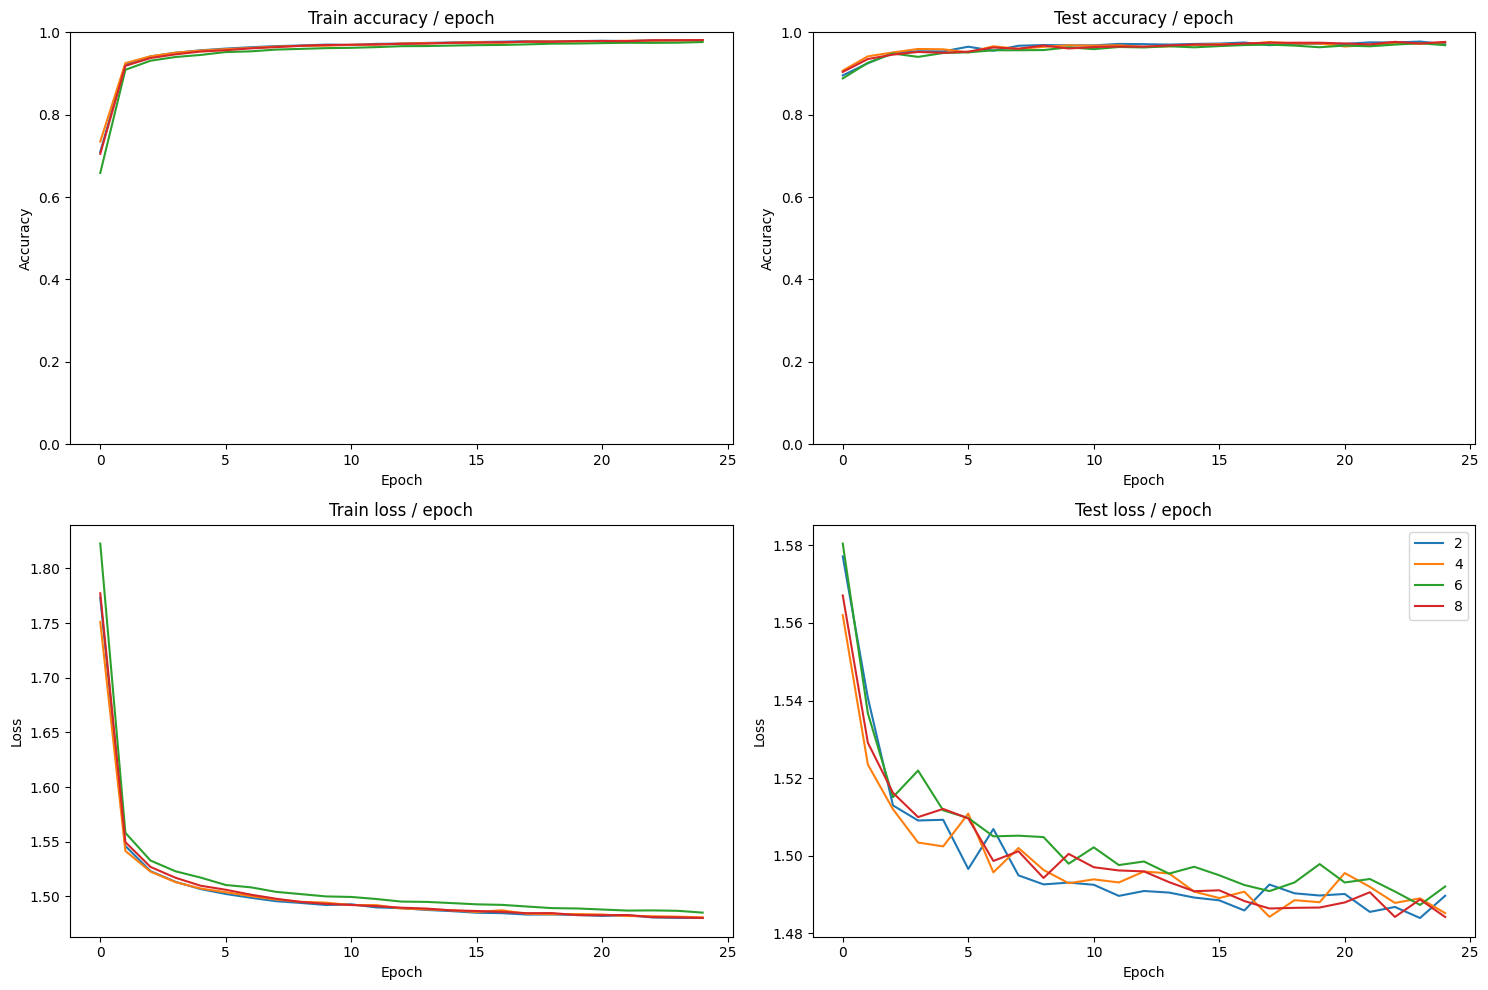

In [ ]:
plot_plot_optimizers(plot_optimizers_mlp_ratio, 'mlp_ratio_influence')

# Q8: larger transformers

Try to use bigger transformer, for example the ViT-S from the timm library. Test with and without intialization from imagenet.

In [ ]:
!pip install timm

a) Load the model using the timm library without pretrained wewights. Try to apply it directly on a tensor with the same MNIST images resolution. What it is the problem and why we have it? Explain if we have also such problem with CNNs. As ViT takes RGB images, the input tensor should have 3 channels.

In [ ]:
import timm

In [ ]:
model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=10)
try:
    model(torch.randn(1, 1, 28, 28))
except AssertionError as err:
    print(err)

Input height (28) doesn't match model (224).


**Input height (28) doesn't match model (224).**

**Vision Transformer input size note**

The model `vit_base_patch16_224` is trained on **224×224** RGB images from ImageNet. In the first ViT layer, the image is split into fixed-size patches and each patch is embedded into a vector. It’s important to keep the input size the model was designed for.

In this case, it resizes the input images to **224×224** RGB. However, be aware that resizing can distort aspect ratios and may affect performance. Consider resize + (center) crop or letterboxing to reduce distortion.

For `patch_size = 16`, the number of patch tokens is
$$
N_{\text{patch}}=\left(\frac{224}{16}\right)^2 = 14^2 = 196,
$$
plus one class token, totaling **197** tokens.


In [ ]:
x = torch.randn(32, 1, 28, 28)
x = x.repeat(1, 3, 8, 8) # adapt number of channels to fit in ViT
# by coping the image and not resizing yet (see next cell)
display(x.size())
model(x).shape

torch.Size([32, 3, 224, 224])

torch.Size([32, 10])

b) There is a trcik in timm that allows to use pretrained models with different image resolution and number of classes. Try to reload the model to be able to use on MNIST images:

In [ ]:
data_cfg = timm.data.resolve_data_config(model.pretrained_cfg)
data_cfg # figure out which transformations were used for a given pretrained model
{'input_size': (3, 224, 224),
 'interpolation': 'bicubic',
 'mean': (0.5, 0.5, 0.5),
 'std': (0.5, 0.5, 0.5),
 'crop_pct': 0.9,
 'crop_mode': 'center'}
transform = timm.data.create_transform(**data_cfg)
transform_rgb = lambda x: transform(x.convert('RGB'))

In [ ]:
model.cuda()
train_dataset = torchvision.datasets.MNIST('.', train=True, download=True, transform=transform_rgb)
test_dataset = torchvision.datasets.MNIST('.', train=False, download=True, transform=transform_rgb)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, )
test_loader = DataLoader(test_dataset, batch_size=64)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.69MB/s]


c) redo the training with the pretrained ViT-S





In [ ]:
stats_vit = main(model=model, epochs=15, tqdm_batch=True, lr=0.01)


NameError: name 'main' is not defined

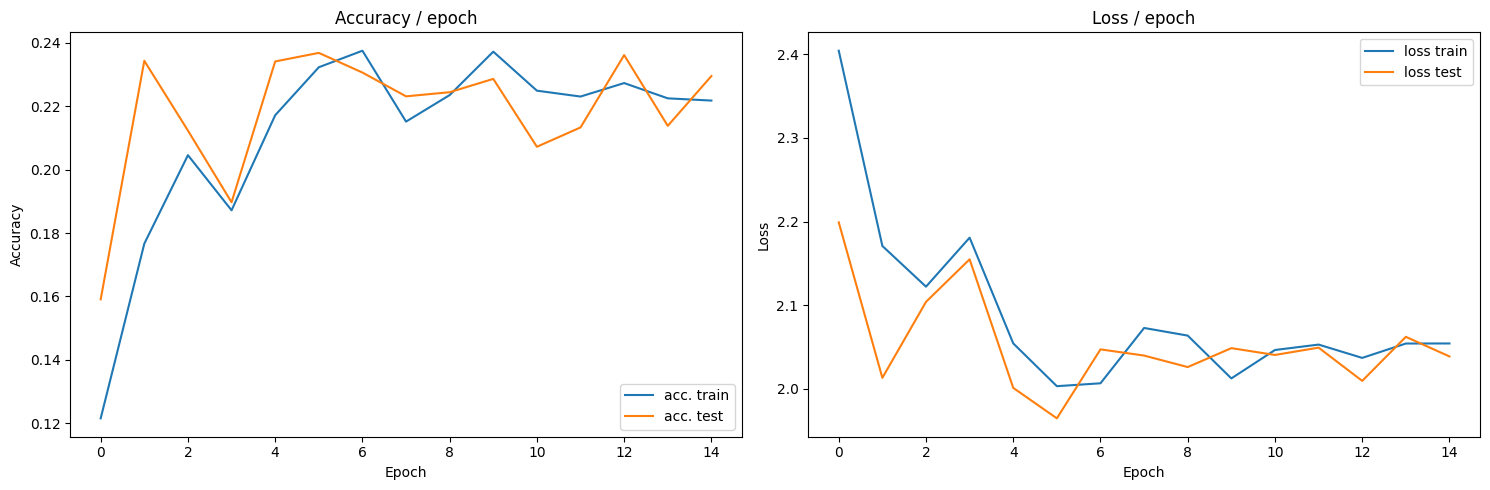

In [ ]:
plt.figure(figsize=(15, 5))
# plt.clf()
plt.subplot(1, 2, 1)
plt.plot(np.array(stats_vit[0]), label="acc. train")
plt.plot(np.array(stats_vit[1]), label="acc. test")
plt.title("Accuracy / epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(np.array(stats_vit[2]), label="loss train")
plt.plot(np.array(stats_vit[3]), label="loss test")
plt.title("Loss / epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("stats_vit.pdf", dpi=100, bbox_inches="tight")
plt.show()

c) redo the training but with the ViT-S pretrained on ImageNet

In [ ]:
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=10).cuda()
stats_pretrained = main(model=model, epochs=10, tqdm_batch=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

100%|██████████| 938/938 [15:03<00:00,  1.04it/s]

acc_train 0.359 | acc_test 0.529:   0%|          | 0/10 [16:05<?, ?it/s]
acc_train 0.359 | acc_test 0.529:  10%|█         | 1/10 [16:05<2:24:52, 965.86s/it]
acc_train 0.599 | acc_test 0.670:  10%|█         | 1/10 [32:08<2:24:52, 965.86s/it]
acc_train 0.599 | acc_test 0.670:  20%|██        | 2/10 [32:08<2:08:33, 964.19s/it]
acc_train 0.651 | acc_test 0.435:  20%|██        | 2/10 [48:09<2:08:33, 964.19s/it]
acc_train 0.651 | acc_test 0.435:  30%|███       | 3/10 [48:09<1:52:16, 962.40s/it]
acc_train 0.637 | acc_test 0.738:  30%|███       | 3/10 [1:04:06<1:52:16, 962.40s/it]
acc_train 0.637 | acc_test 0.738:  40%|████      | 4/10 [1:04:06<1:36:01, 960.22s/it]
acc_train 0.759 | acc_test 0.796:  40%|████      | 4/10 [1:20:01<1:36:01, 960.22s/it]
acc_train 0.759 | acc_test 0.796:  50%|█████     | 5/10 [1:20:01<1:19:53, 958.63s/it]
acc_train 0.736 | acc_test 0.789:  50%|█████     | 5/10 [1:35:56<1:19:53, 958.63s/it]
acc_train 0.736 | acc_test

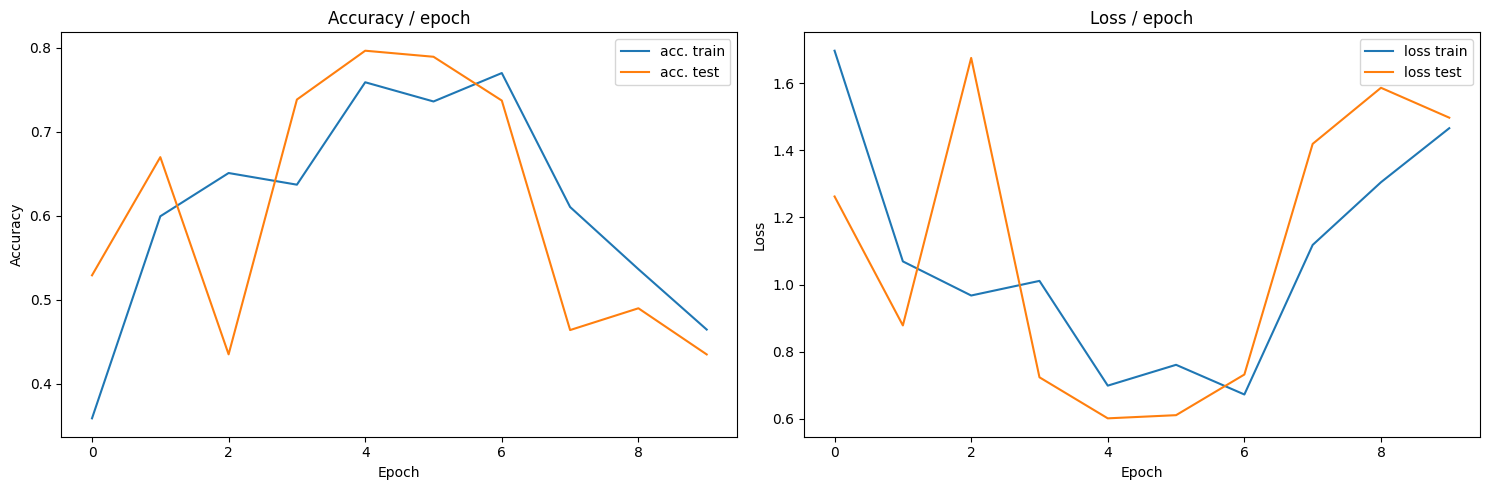

In [ ]:
plt.figure(figsize=(15, 5))
# plt.clf()
plt.subplot(1, 2, 1)
plt.plot(np.array(stats_pretrained[0]), label="acc. train")
plt.plot(np.array(stats_pretrained[1]), label="acc. test")
plt.title("Accuracy / epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(np.array(stats_pretrained[2]), label="loss train")
plt.plot(np.array(stats_pretrained[3]), label="loss test")
plt.title("Loss / epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("stats_vit_pretrained.pdf", dpi=100, bbox_inches="tight")

d) Comment the final results and provide some ideas on how to make transformer work on small datasets. You can take inspiration from some recent work.